# Тема 1. Введение: что такое временной ряд и почему это не “обычные данные”

Мы идём по первой лекции и собираем базу:
- что такое временной ряд (ВР)
- чем ВР отличается от случайной выборки
- почему возникает ложная корреляция
- базовые компоненты ВР
- зачем делать преобразования (логарифмы, разности) — на уровне интуиции

Данные будем **генерировать** сами: так проще понять механику процессов.

In [26]:
# Базовые импорты для темы 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Что такое временной ряд

**Определение (идея из лекции):**  
Временной ряд — это совокупность наблюдений величины в последовательные моменты времени:

\[
\{Y_t,\; t = 1,2,\dots,T\}
\]

Где:
- \(t\) — момент времени (индекс)
- \(Y_t\) — значение показателя в момент \(t\)

Ключевая мысль из лекции:  
**Временной ряд — это реализация случайного (стохастического) процесса.**  
То есть мы видим одну траекторию, а “внутри” есть вероятностный механизм, который её порождает.

## 2. Пространственная выборка vs временной ряд

В лекции подчёркивается разница:

- **Пространственная выборка:** \(Y_i\) (например, ВВП по странам в 2022)  
  Часто предполагается: наблюдения независимы (или хотя бы “почти”).

- **Временной ряд:** \(Y_t\) (например, ВВП одной страны по годам)  
  Наблюдения обычно **зависимы**: \(Y_t\) связан с прошлым \(Y_{t-1}, Y_{t-2}, \dots\)

Отсюда важный вывод:  
**Нельзя механически переносить свойства и методы для случайной выборки на временные ряды.**

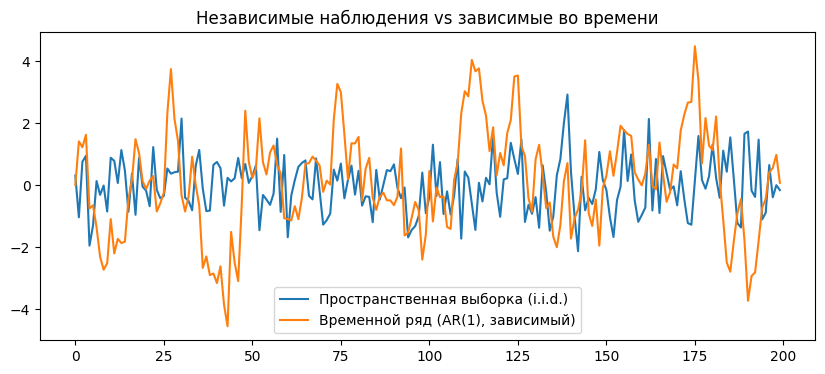

In [3]:
# Сгенерируем "пространственную выборку": независимые наблюдения
rng = np.random.default_rng(42)
n = 200
sample = rng.normal(loc=0.0, scale=1.0, size=n)

# Сгенерируем простой временной ряд с зависимостью: AR(1): y_t = 0.8 y_{t-1} + e_t
T = 200
e = rng.normal(0.0, 1.0, size=T)
y = np.zeros(T)
phi = 0.8
for t in range(1, T):
    y[t] = phi * y[t - 1] + e[t]

fig = plt.figure(figsize=(10, 4))
plt.plot(sample, label="Пространственная выборка (i.i.d.)")
plt.plot(y, label="Временной ряд (AR(1), зависимый)")
plt.title("Независимые наблюдения vs зависимые во времени")
plt.legend()
plt.show()

### Что мы видим на графике?

- “Пространственная выборка” выглядит как шум вокруг среднего — без памяти.
- AR(1) выглядит “гладче”: значения тянутся друг за другом, потому что есть зависимость от прошлого.

Это и есть интуитивная разница: **у временного ряда есть память**.

## 3. Проблема ложной корреляции (spurious correlation)

В лекции приводится важный кейс: можно получить высокую корреляцию между двумя рядами,
даже если они не связаны причинно — особенно если оба ряда **нестационарны** (например, случайные блуждания).

Пример-идея из лекции:
\[
x_t = x_{t-1} + \varepsilon_t,\quad y_t = y_{t-1} + v_t
\]
Даже если \(\varepsilon_t\) и \(v_t\) независимы, корреляция между \(x_t\) и \(y_t\) может быть большой.

Интуиция:
- оба ряда “ползут” и накапливают случайные изменения
- из-за этого кажется, что они “ходят вместе”, хотя это просто совпадение траекторий

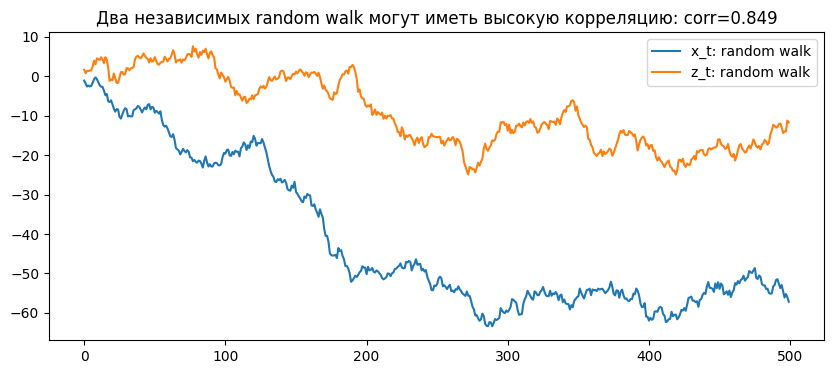

In [18]:
# Демонстрация ложной корреляции: два независимых случайных блуждания
rng = np.random.default_rng(10)
T = 500

eps = rng.normal(0.0, 1.0, size=T)
nu = rng.normal(0.0, 1.0, size=T)

x = np.cumsum(eps)  # random walk
z = np.cumsum(nu)   # random walk

corr = np.corrcoef(x, z)[0, 1]

fig = plt.figure(figsize=(10, 4))
plt.plot(x, label="x_t: random walk")
plt.plot(z, label="z_t: random walk")
plt.title(f"Два независимых random walk могут иметь высокую корреляцию: corr={corr:.3f}")
plt.legend()
plt.show()

### Вывод

Корреляция между временными рядами **не означает** реальной связи.

Поэтому во временных рядах мы постоянно думаем про:
- стационарность
- тренды/разности
- корректные модели зависимости

К этому мы вернёмся в следующих темах.

## 4. Зачем преобразовывать временной ряд?

В лекции (раздел “ВР: преобразования”) мотивы такие:

1) **Сезонная корректировка** — убрать сезонность  
2) **Дифференцирование (разности), детрендирование** — привести ряд к стационарному виду  
3) **Логарифмирование** — стабилизировать дисперсию (когда разброс растёт с уровнем)

Интуитивно:
- логарифм “сжимает” большие значения
- разности убирают тренд и делают ряд более “ровным”

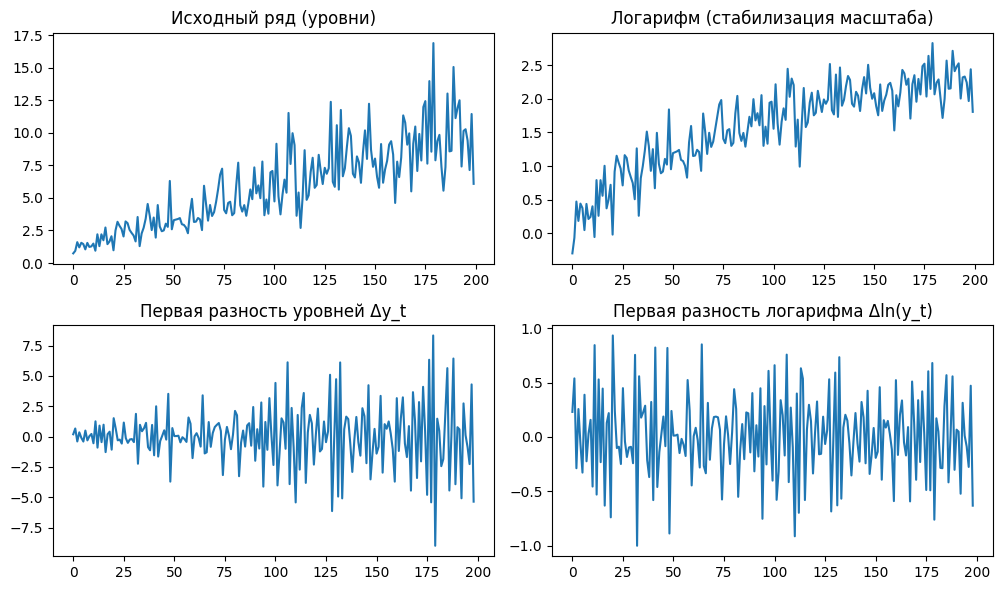

In [19]:
# Мини-демо: логарифмирование и разности на синтетическом "растущем" ряде

rng = np.random.default_rng(123)
T = 200
trend = np.linspace(1, 10, T)
noise = rng.normal(0.0, 0.3, size=T)

# Положительный ряд с растущим уровнем
y_level = trend * np.exp(noise)

y_log = np.log(y_level)
y_diff = np.diff(y_level)
y_logdiff = np.diff(y_log)

fig = plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.plot(y_level)
plt.title("Исходный ряд (уровни)")

plt.subplot(2, 2, 2)
plt.plot(y_log)
plt.title("Логарифм (стабилизация масштаба)")

plt.subplot(2, 2, 3)
plt.plot(y_diff)
plt.title("Первая разность уровней Δy_t")

plt.subplot(2, 2, 4)
plt.plot(y_logdiff)
plt.title("Первая разность логарифма Δln(y_t)")

plt.tight_layout()
plt.show()

### Интуитивные выводы по преобразованиям

- **Логарифм** полезен, когда вариативность растёт вместе с уровнем ряда.
- **Первая разность** убирает “ползущий” тренд (часто).
- **Разность логарифма** ≈ процентное изменение (часто используют в финансах как лог-доходность).

## 5. Компоненты временного ряда

В лекции перечисляются 4 типа факторов (Айвазян):

- (A) долговременные → **тренд**
- (B) сезонные → периодически повторяющиеся колебания
- (C) циклические → колебания, связанные с длительными циклами
- (D) случайные → шум

Схематично:
\[
Y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Cycle}_t + \varepsilon_t
\]

Важно: это **концептуальная декомпозиция** — она помогает думать о данных,
даже если мы ещё не строим сложные модели.

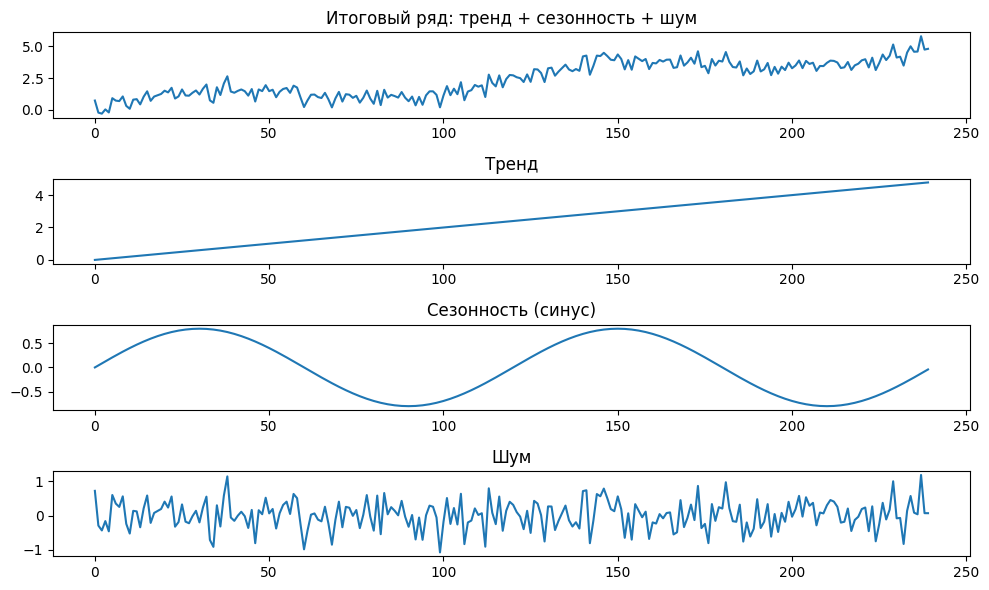

In [25]:
# Сгенерируем ряд как сумму компонентов: тренд + сезонность + шум

rng = np.random.default_rng(202)
T = 240
t = np.arange(T)

trend = 0.02 * t
seasonal = 0.8 * np.sin(0.2 * np.pi * t / 12)  # "месячная" сезонность (период 12)
noise = rng.normal(0.0, 0.4, size=T)

y = trend + seasonal + noise

fig = plt.figure(figsize=(10, 6))

plt.subplot(4, 1, 1)
plt.plot(y)
plt.title("Итоговый ряд: тренд + сезонность + шум")

plt.subplot(4, 1, 2)
plt.plot(trend)
plt.title("Тренд")

plt.subplot(4, 1, 3)
plt.plot(seasonal)
plt.title("Сезонность (синус)")

plt.subplot(4, 1, 4)
plt.plot(noise)
plt.title("Шум")

plt.tight_layout()
plt.show()

## Мини-итог темы 1

Что должно “встать” после этой темы:

1) Временной ряд — это данные во времени, **наблюдения зависимы**.  
2) Поэтому методы для случайной выборки не переносятся напрямую.  
3) Нестационарность может давать **ложные корреляции**.  
4) Мы часто преобразуем ряды (лог, разности), чтобы:
   - стабилизировать дисперсию
   - убрать тренд/сезонность
   - сделать ряд ближе к стационарному
5) Полезно мыслить рядом как суммой компонентов: тренд + сезонность + цикл + шум.

Следующая тема (в следующем ноутбуке):
- среднее/дисперсия/ковариация
- автоковариация
- ACF и PACF (и зачем они нужны)

# Тренд во временных рядах

В этом ноутбуке разбираем:

1. Что такое тренд  
2. Детерминированный vs стохастический тренд  
3. Как проверить наличие тренда  
4. Оценивание линейного тренда через МНК  
5. Интерпретация коэффициентов  

Это центральная тема: тренд = основная долгосрочная динамика ряда.

## 1. Понятие тренда

Тренд — это систематическая долговременная составляющая временного ряда.

Общая идея разложения:

$$
Y_t = f(t) + \varepsilon_t
$$

где:
- $f(t)$ — трендовая компонента
- $\varepsilon_t$ — случайная составляющая

Тренд отвечает за "общее направление движения" ряда.

## 2. Детерминированный тренд

Детерминированный тренд можно записать как функцию времени:

$$
Y_t = \beta_0 + \beta_1 t + \varepsilon_t
$$

Интерпретация:

- $\beta_0$ — уровень в момент $t=0$
- $\beta_1$ — среднее изменение показателя за единицу времени
- $\varepsilon_t$ — шум

Если $\beta_1 > 0$ → рост  
Если $\beta_1 < 0$ → спад

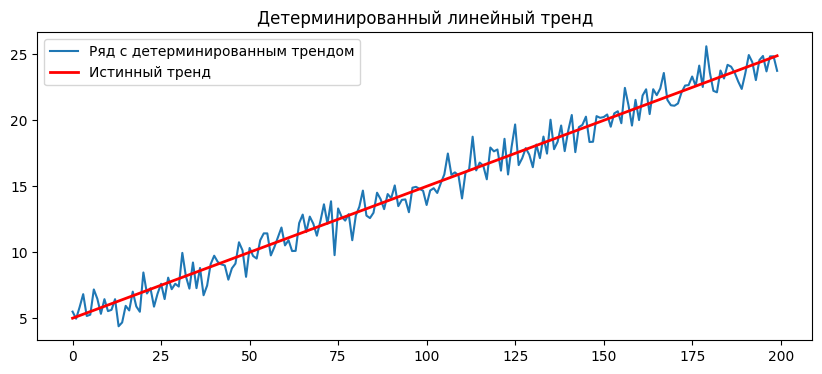

In [27]:
# Генерируем детерминированный линейный тренд

np.random.seed(42)
T = 200
t = np.arange(T)

beta_0 = 5
beta_1 = 0.1

noise = np.random.normal(0, 1, T)
y_det = beta_0 + beta_1 * t + noise

plt.figure(figsize=(10,4))
plt.plot(t, y_det, label="Ряд с детерминированным трендом")
plt.plot(t, beta_0 + beta_1 * t, color="red", linewidth=2, label="Истинный тренд")
plt.legend()
plt.title("Детерминированный линейный тренд")
plt.show()

Интуиция:

Если убрать шум, останется прямая линия.  
Шок сегодня не влияет на уровень завтра.

## 3. Стохастический тренд (случайное блуждание)

Стохастический тренд задаётся:

$$
Y_t = Y_{t-1} + \varepsilon_t
$$

Это случайное блуждание.

Интуиция:

Каждый шок $\varepsilon_t$ накапливается навсегда.
Система "помнит" все прошлые ошибки.

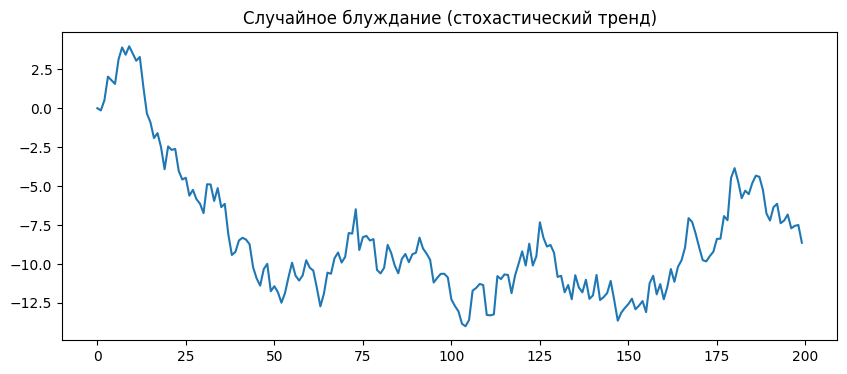

In [30]:
# Генерируем случайное блуждание

np.random.seed(42)
eps = np.random.normal(0, 1, T)

y_rw = np.zeros(T)
for i in range(1, T):
    y_rw[i] = y_rw[i-1] + eps[i]

plt.figure(figsize=(10,4))
plt.plot(y_rw)
plt.title("Случайное блуждание (стохастический тренд)")
plt.show()

Главное отличие:

- При детерминированном тренде шоки временные.
- При стохастическом тренде шоки постоянные.

Это принципиально разные типы нестационарности.

## 4. Проверка наличия тренда

Идея из лекции:

Проверяем гипотезу:

$$
H_0: E(Y_t) = \mu = const
$$

против

$$
H_1: E(Y_t) \neq const
$$

Если среднее не постоянно — есть тренд.

### Критерий серий (Runs test)

Идея:

Если ряд случайный, значения не должны "слишком долго"
находиться по одну сторону медианы.

Алгоритм:

1. Найти медиану
2. Присвоить:
   + если $Y_t > Me$
   - если $Y_t < Me$
3. Посчитать число серий

In [31]:
def runs_test(series):
    median = np.median(series)
    signs = np.where(series > median, 1, 0)
    
    runs = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            runs += 1
    
    n1 = np.sum(signs)
    n0 = len(signs) - n1
    n = n0 + n1
    
    mean_r = (2*n0*n1)/n + 1
    var_r = (2*n0*n1*(2*n0*n1 - n))/(n**2*(n-1))
    
    z = (runs - mean_r)/np.sqrt(var_r)
    
    return runs, z

runs_det, z_det = runs_test(y_det)
runs_rw, z_rw = runs_test(y_rw)

runs_det, z_det, runs_rw, z_rw

(10, np.float64(-12.90180082959215), 21, np.float64(-11.342242487553538))

Интерпретация:

Если |z| > 1.96 → отвергаем $H_0$ на 5% уровне.

Обычно для трендового ряда гипотеза случайности отвергается.

## 5. Оценивание тренда методом наименьших квадратов (OLS)

Модель:

$$
Y_t = \beta_0 + \beta_1 t + \varepsilon_t
$$

Оценки выбираются так, чтобы минимизировать:

$$
\sum (Y_t - \hat{Y}_t)^2
$$

In [32]:
# Оценим линейную регрессию вручную через numpy

X = np.column_stack((np.ones(T), t))
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y_det

beta_hat

array([4.84522523, 0.10114577])

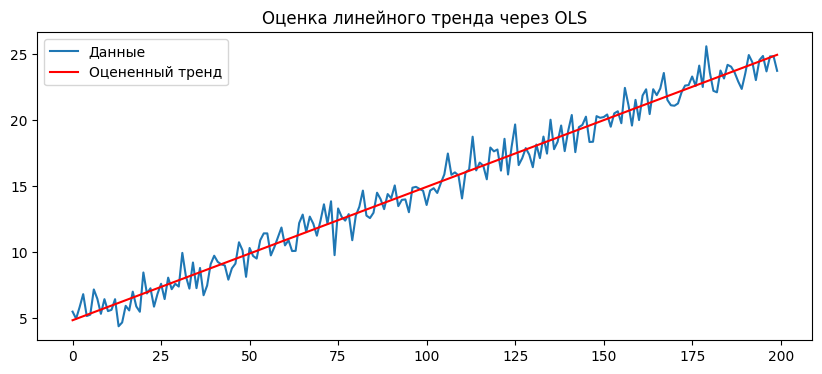

In [33]:
y_hat = X @ beta_hat

plt.figure(figsize=(10,4))
plt.plot(t, y_det, label="Данные")
plt.plot(t, y_hat, color="red", label="Оцененный тренд")
plt.legend()
plt.title("Оценка линейного тренда через OLS")
plt.show()

Интерпретация:

- $\hat{\beta}_1$ показывает средний рост за период.
- Если коэффициент значим — тренд статистически подтвержден.

Позже мы добавим t-тест и R².

## Что должно стать понятным

1. Тренд — это систематическая часть ряда.
2. Есть два типа:
   - детерминированный
   - стохастический
3. Стохастический тренд делает ряд принципиально нестационарным.
4. Линейный тренд можно оценить через OLS.
5. Проверка случайности помогает выявить наличие тренда.

Следующая тема:
Методы выделения тренда:
- скользящие средние
- взвешенные СС
- HP-фильтр

# Методы выделения тренда (сглаживание)

Мы уже знаем, что тренд — это долгосрочная систематическая часть ряда.

Теперь вопрос:

Как его **оценить**, если мы не знаем явную форму $f(t)$?

Ответ: использовать методы сглаживания.

## 1. Простая скользящая средняя (SMA)

Идея:

Тренд в момент $t$ — это среднее последних $m$ наблюдений.

$$
\hat{T}_t = \frac{1}{m} \sum_{i=0}^{m-1} Y_{t-i}
$$

где:
- $m$ — ширина окна сглаживания.

Интуиция:

Мы "срезаем" краткосрочные колебания,
оставляя медленную динамику.

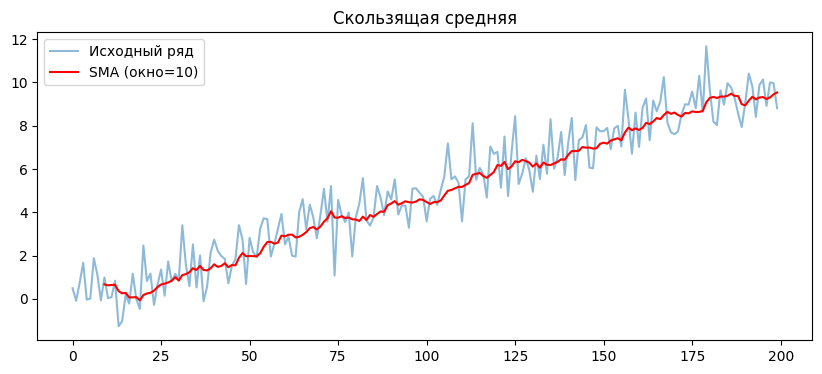

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
T = 200
t = np.arange(T)

# Ряд с трендом + шумом
y = 0.05*t + np.random.normal(0, 1, T)

# Скользящая средняя
window = 10
y_sma = pd.Series(y).rolling(window=window).mean()

plt.figure(figsize=(10,4))
plt.plot(y, alpha=0.5, label="Исходный ряд")
plt.plot(y_sma, color="red", label=f"SMA (окно={window})")
plt.legend()
plt.title("Скользящая средняя")
plt.show()

Что важно:

- Чем больше окно — тем сильнее сглаживание.
- Но при этом появляется лаг (запаздывание).

## 2. Взвешенная скользящая средняя

Иногда хотим, чтобы более свежие наблюдения имели больший вес.

$$
\hat{T}_t = \sum_{i=0}^{m-1} w_i Y_{t-i}
$$

где:

$$
\sum w_i = 1
$$

Интуиция:

Недавние данные важнее старых.

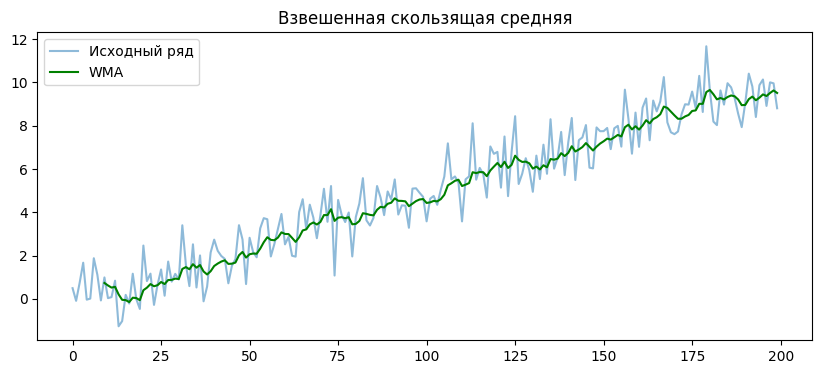

In [35]:
# Пример линейных весов
weights = np.arange(1, window+1)
weights = weights / weights.sum()

def weighted_ma(series, weights):
    return series.rolling(len(weights)).apply(
        lambda x: np.dot(x, weights),
        raw=True
    )

y_wma = weighted_ma(pd.Series(y), weights)

plt.figure(figsize=(10,4))
plt.plot(y, alpha=0.5, label="Исходный ряд")
plt.plot(y_wma, color="green", label="WMA")
plt.legend()
plt.title("Взвешенная скользящая средняя")
plt.show()

Отличие от SMA:

- Меньше запаздывание
- Быстрее реагирует на изменения

## 3. Полиномиальный тренд

Иногда тренд нелинейный.

Можно оценить:

$$
Y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \varepsilon_t
$$

Это позволяет моделировать ускоряющийся рост или спад.

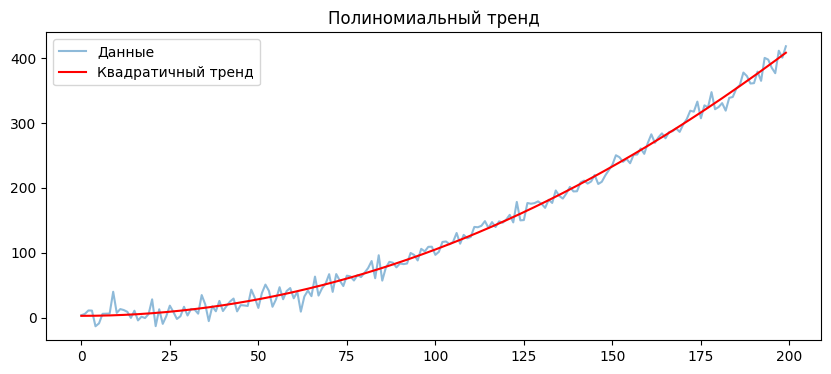

In [36]:
# Квадратичный тренд
y_poly = 0.01*t**2 + 0.05*t + np.random.normal(0, 10, T)

X = np.column_stack((np.ones(T), t, t**2))
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y_poly
y_hat = X @ beta_hat

plt.figure(figsize=(10,4))
plt.plot(y_poly, alpha=0.5, label="Данные")
plt.plot(y_hat, color="red", label="Квадратичный тренд")
plt.legend()
plt.title("Полиномиальный тренд")
plt.show()

## 4. HP-фильтр

Идея:

Разделить ряд на:

$$
Y_t = T_t + C_t
$$

где:
- $T_t$ — гладкий тренд
- $C_t$ — циклическая компонента

HP-фильтр выбирает $T_t$, минимизируя:

$$
\sum (Y_t - T_t)^2 + \lambda \sum (T_{t+1} - 2T_t + T_{t-1})^2
$$

Первый член — близость к данным  
Второй — гладкость тренда  

$\lambda$ — параметр сглаживания.

/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


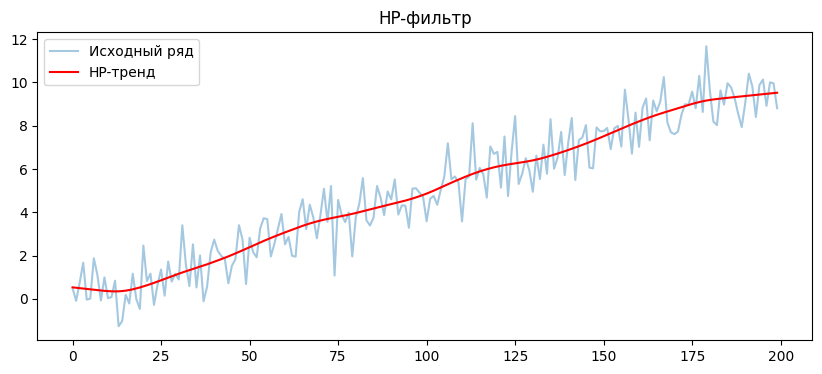

In [37]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend = hpfilter(y, lamb=1600)

plt.figure(figsize=(10,4))
plt.plot(y, alpha=0.4, label="Исходный ряд")
plt.plot(trend, color="red", label="HP-тренд")
plt.legend()
plt.title("HP-фильтр")
plt.show()

Интуиция параметра $\lambda$:

- Малое $\lambda$ → тренд более "гибкий"
- Большое $\lambda$ → тренд очень гладкий

Типичные значения:
- 1600 — квартальные данные
- 100 — годовые
- 14400 — месячные

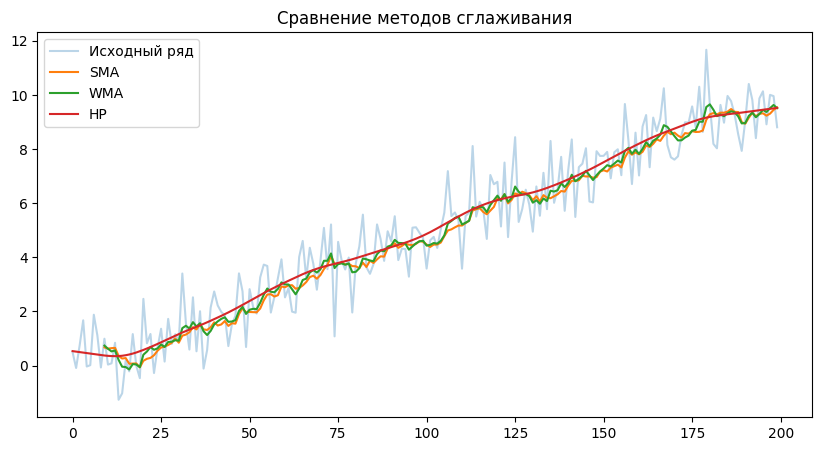

In [38]:
plt.figure(figsize=(10,5))
plt.plot(y, alpha=0.3, label="Исходный ряд")
plt.plot(y_sma, label="SMA")
plt.plot(y_wma, label="WMA")
plt.plot(trend, label="HP")
plt.legend()
plt.title("Сравнение методов сглаживания")
plt.show()

## Итоги

1. Скользящая средняя — простой способ убрать шум.
2. Взвешенная версия быстрее реагирует.
3. Полиномиальная регрессия — параметрический подход.
4. HP-фильтр — популярный инструмент макроэкономики.

Главная идея:

Методы сглаживания помогают выделить **долгосрочную динамику**,
но они не решают проблему стохастической нестационарности.

Дальше логично перейти к:

- Стационарности
- Автокорреляции
- AR/MA моделям